## Load Stuff

In [1]:
import torch
from mario_gpt import MarioDataset, MarioLM, TrainingConfig, MarioGPTTrainer
from mario_gpt.utils import view_level, convert_level_to_png, join_list_of_list, characterize

In [2]:
BASE = "distilgpt2"

In [3]:
from transformers import AutoConfig, AutoModelWithLMHead

In [4]:
mario_lm = MarioLM()

Using shyamsn97/Mario-GPT2-700-context-length lm


/opt/conda/lib/python3.10/site-packages/transformers-4.46.3-py3.10.egg/transformers/models/auto/modeling_auto.py:1833: FutureWarning: The class `AutoModelWithLMHead` is deprecated and will be removed in a future version. Please use `AutoModelForCausalLM` for causal language models, `AutoModelForMaskedLM` for masked language models and `AutoModelForSeq2SeqLM` for encoder-decoder models.
  warnings.warn(


Using shyamsn97/Mario-GPT2-700-context-length tokenizer


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


### Load Dataset (Optional)

In [5]:
dataset = MarioDataset(tokenizer=mario_lm.tokenizer, folder_path='/mario-gpt/txt')

Token indices sequence length is longer than the specified maximum sequence length for this model (3360 > 1024). Running this sequence through the model will result in indexing errors


In [6]:
view_level(dataset.data[1]["input_ids"][:700], mario_lm.tokenizer)

['--------------------------------------------------',
 '--------------------------------------------------',
 '--------------------------------------------------',
 '--------------------------------------------------',
 '--------------------------------------------------',
 '----------------------------------------C---------',
 '--------------------------------C-----------------',
 '-----------------------------oo-----------------oo',
 '----------------------------o------------------o--',
 '------------!---?!------oo-------------SCS--------',
 '-----------------------o-----XXXXXX---------------',
 '-----------------------------XXXXXX---------------',
 '------------------g-----XXXXXXXXXXX------------XXX',
 'XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX']

/opt/conda/lib/python3.10/site-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


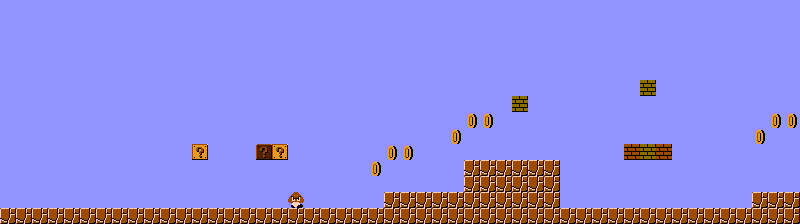

In [7]:
img = convert_level_to_png(dataset.data[1]["input_ids"][:700],  mario_lm.tokenizer)[0]
img

### Setup training

## aaaaaaaaa

In [13]:
import os
from dataclasses import asdict, dataclass
from typing import Any, Optional, Tuple

import numpy as np
import torch

# import torch.nn.functional as F
# from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, MSELoss # noqa
from accelerate import Accelerator
from PIL import ImageDraw
from torch.nn import CrossEntropyLoss  # noqa
from torch.optim.optimizer import Optimizer
from torch.utils.data import Dataset
from tqdm import tqdm
from transformers import AdamW, PreTrainedModel, get_linear_schedule_with_warmup

from mario_gpt.dataset import MarioDataset
from mario_gpt.lm import BaseMarioLM, MarioLM


@dataclass
class TrainingConfig:
    gradient_accumulation_steps: int = 1
    mixed_precision: str = (
        "no"  # `no` for float32, `fp16` for automatic mixed precision
    )
    output_dir: str = (
        "Mario-GPT2-700-context-length"  # the model name locally and on the HF Hub
    )
    learning_rate: float = 5e-4
    epsilon: float = 1e-9
    lr_warmup_steps: int = 1000
    batch_size: int = 4
    total_steps: int = 50000
    mask_proportion: float = 0.0
    eval_iteration: int = 1000
    save_iteration: int = 5000

    def pretty_print(self):
        print("================== Training Config ==================")
        d = asdict(self)
        for k in d:
            print(f"{k} -- {d[k]}")
        print("================== MarioLM ==================")


class MarioGPTTrainer:
    def __init__(
        self,
        mario_lm: BaseMarioLM,
        train_dataset: MarioDataset,
        config: Optional[TrainingConfig] = None,
        optimizer: Optional[Optimizer] = None,
        lr_scheduler: Optional[Any] = None,
    ):
        self.mario_lm = mario_lm
        self.train_dataset = train_dataset

        self.config = config

        if config is None:
            self.config = TrainingConfig()

        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler

        if optimizer is None:
            self.optimizer = self.create_optimizer(self.config)
        if lr_scheduler is None:
            self.lr_scheduler = self.create_lr_scheduler(self.config, self.optimizer)

        self.accelerator = self.create_accelerator(self.config)

    def prepare(self) -> Tuple[PreTrainedModel, Optimizer, Any]:
        return self.accelerator.prepare(
            self.mario_lm.lm, self.optimizer, self.lr_scheduler
        )

    def create_optimizer(self, config: Any) -> Optimizer:
        params = self.mario_lm.lm.parameters()
        return AdamW(params, lr=config.learning_rate, eps=config.epsilon)

    def create_lr_scheduler(self, config: Any, optimizer: Optimizer) -> Any:
        return get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=config.lr_warmup_steps,
            num_training_steps=config.total_steps,
        )

    def create_accelerator(self, config: Any) -> Accelerator:
        return Accelerator(
            mixed_precision=config.mixed_precision,
            gradient_accumulation_steps=config.gradient_accumulation_steps,
            log_with="tensorboard",
            project_dir=config.output_dir,
        )

    def unwrap(self) -> BaseMarioLM:
        return MarioLM(
            lm=self.accelerator.unwrap(self.mario_lm.lm),
            tokenizer=self.mario_lm.tokenizer,
            context_len=self.mario_lm.context_len,
            prompter=self.mario_lm.prompter,
        )

    def sample_from_dataset(
        self, dataset: Dataset, batch_size: int
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        indices = torch.randint(low=0, high=len(dataset), size=(batch_size,)).long()
        batch = [dataset[i] for i in indices]
        input_ids, attention_masks = zip(*batch)
        return torch.stack(input_ids), torch.stack(attention_masks)

    def train_iter(
        self,
        accelerator: Accelerator,
        model: PreTrainedModel,
        train_dataset: MarioDataset,
        optimizer: Any,
        scheduler: Any,
        batch_size: int = 4,
    ):
        device = accelerator.device
        total_train_loss = 0

        # Use the new sampling method
        b_input_ids, attention_masks = self.sample_from_dataset(train_dataset, batch_size)
        b_input_ids = b_input_ids.view(batch_size, -1).to(device)
        b_labels = b_input_ids.clone()
        attention_masks = attention_masks.to(device)

        encoder_hidden_states = None
        str_levels = []
        encoder_hidden_states = []
        for level in b_input_ids:
            _, encoder_hidden_state, _, str_level = self.mario_lm.prompter(level)
            str_levels.append(str_level)
            encoder_hidden_states.append(encoder_hidden_state)
        encoder_hidden_states = torch.stack(encoder_hidden_states, dim=0).view(
            batch_size, 1, -1
        )

        with accelerator.accumulate(model):
            model.zero_grad()
            outputs = model(
                input_ids=b_input_ids.to(device),
                labels=b_labels,
                attention_mask=attention_masks,
                encoder_hidden_states=encoder_hidden_states,
                token_type_ids=None,
            )
            loss = outputs.loss

            batch_loss = loss.item()
            total_train_loss += batch_loss

            loss.backward()
            optimizer.step()
            scheduler.step()

        grad_dict = {}
        for n, W in model.named_parameters():
            if W.grad is not None:
                grad_dict["{}_grad".format(n)] = float(torch.sum(W.grad).item())

        return total_train_loss / batch_size, grad_dict

    def train(
        self,
        total_steps: Optional[int] = None,
        batch_size: Optional[int] = None,
    ):
        if total_steps is None:
            total_steps = self.config.total_steps
        if batch_size is None:
            batch_size = self.config.batch_size

        self.accelerator.init_trackers("mario-gpt")

        checkpoint_path = self.config.output_dir
        logdir = os.path.abspath(self.accelerator.logging_dir)

        print(f"Training for {total_steps} Iterations and batch_size {batch_size}")
        if getattr(self.config, "pretty_print", None) is not None:
            self.config.pretty_print()
        print(f"Follow tensorboard with: python -m tensorboard.main --logdir {logdir}")

        model, optimizer, lr_scheduler = self.prepare()

        bar = tqdm(np.arange(total_steps))
        model.train()

        for i in bar:
            loss, grad_dict = self.train_iter(
                self.accelerator,
                model,
                self.train_dataset,
                optimizer,
                lr_scheduler,
                batch_size,
            )
            logs = {"loss": loss, "last_lr": lr_scheduler.get_last_lr()[0]}
            bar.set_description(f"{logs}")
            self.accelerator.log({**logs, **grad_dict}, step=i)

            if (i + 1) % self.config.eval_iteration == 0:
                print("Evaluating...")
                with torch.no_grad():
                    try:
                        if self.config.mask_proportion <= 0.0:
                            (
                                prompt,
                                _,
                                _,
                                _,
                            ) = self.mario_lm.prompter(sample_prompt=True)
                            out = self.mario_lm.sample(
                                prompts=[prompt],
                                num_steps=1400,
                                temperature=2.0,
                                use_tqdm=True,
                            )
                            draw = ImageDraw.Draw(out.img)
                            draw.text((0, 0), prompt, (0, 0, 0))
                            tracker = self.accelerator.get_tracker("tensorboard")
                            tracker.add_image(
                                "image", np.array(out.img), i, dataformats="HWC"
                            )
                    except Exception as e:
                        print("Failed to evaluate!", e)
                model.train()
            if (i + 1) % self.config.save_iteration == 0:
                self.mario_lm.save_model(checkpoint_path, i)


## aaaa end

In [14]:
config = TrainingConfig(save_iteration=10)

In [15]:
trainer = MarioGPTTrainer(mario_lm, dataset, config=config)

/opt/conda/lib/python3.10/site-packages/transformers-4.46.3-py3.10.egg/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [16]:
trainer.train(100, batch_size=1)

Training for 100 Iterations and batch_size 1
================== Training Config ==================
gradient_accumulation_steps -- 1
mixed_precision -- no
output_dir -- Mario-GPT2-700-context-length
learning_rate -- 0.0005
epsilon -- 1e-09
lr_warmup_steps -- 1000
batch_size -- 4
total_steps -- 50000
mask_proportion -- 0.0
eval_iteration -- 1000
save_iteration -- 10
================== MarioLM ==================
Follow tensorboard with: python -m tensorboard.main --logdir /mario-gpt/Mario-GPT2-700-context-length


{'loss': 1.1560299396514893, 'last_lr': 5e-05}: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.90it/s]
